# E-Commerce Checkout Optimization: A/B Test & Segment Analysis

## Executive Summary
**Objective:** Evaluate a redesigned checkout page (Variant B) against the existing page (Variant A).

**The "Data Trap":** While Variant B showed an overall statistically significant lift, a deep-dive segment analysis revealed a catastrophic failure on mobile devices. This project demonstrates the danger of **Simpson's Paradox** and the importance of granular data analysis.

## Part 1: Setup & Data Loading
We begin by importing our technical stack and loading the simulated dataset of 100,000 user sessions.

In [2]:
import pandas as pd
import numpy as np
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic style for plots
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('checkout_ab_test_data.csv')
df.head()

,user_id,device,group,converted
0,1,Desktop,Treatment,0
1,2,Mobile,Treatment,0
2,3,Desktop,Control,0
3,4,Desktop,Control,0
4,5,Desktop,Control,0


## Part 2: Data Cleaning
Real-world data is often noisy. Here, we handle duplicate entries and verify that our experiment traffic was split evenly (50/50).

In [3]:
# 1. Check for and remove duplicates (Handling "Double-Clicks")
print(f"Original row count: {len(df)}")
df_clean = df.drop_duplicates(subset='user_id', keep='first')
print(f"Cleaned row count: {len(df_clean)}")

# 2. Verify the 50/50 traffic split (Sanity Check)
print("\nTraffic Split:")
print(df_clean['group'].value_counts(normalize=True))

Original row count: 100500
Cleaned row count: 100000

Traffic Split:
group
Treatment    0.50166
Control      0.49834
Name: proportion, dtype: float64


## Part 3: Exploratory Data Analysis (EDA)
We calculate the baseline rates and then slice by device type to see if the "Treatment" group's success is consistent.

Overall Conversion Rates (%):
group
Control      10.027291
Treatment    12.931069
Name: converted, dtype: float64

Segmented Conversion Rates (%):
device   group    
Desktop  Control      10.040845
         Treatment    15.074151
Mobile   Control       9.972801
         Treatment     4.299459
Name: converted, dtype: float64


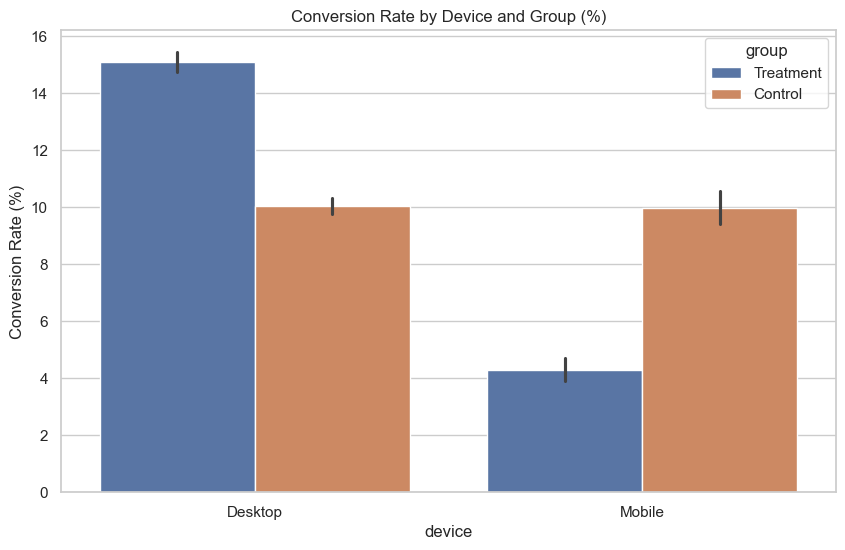

In [4]:
# 3. Calculate Baseline (Overall) Conversion Rates
overall_rates = df_clean.groupby('group')['converted'].mean() * 100
print("Overall Conversion Rates (%):")
print(overall_rates)

# 4. Calculate Segmented Conversion Rates (Exposing the Twist)
segment_rates = df_clean.groupby(['device', 'group'])['converted'].mean() * 100
print("\nSegmented Conversion Rates (%):")
print(segment_rates)

# Visualizing the Paradox
plt.figure(figsize=(10, 6))
sns.barplot(x='device', y='converted', hue='group', data=df_clean, estimator=lambda x: np.mean(x) * 100)
plt.title('Conversion Rate by Device and Group (%)')
plt.ylabel('Conversion Rate (%)')
plt.show()

## Part 4: Statistical Testing (The Z-Test)
Is the overall lift real or random chance? We run a **Two-Proportion Z-Test** to validate the results.

In [5]:
# Isolate the groups
control_results = df_clean[df_clean['group'] == 'Control']['converted']
treatment_results = df_clean[df_clean['group'] == 'Treatment']['converted']

# Calculate successes and observations
successes = [treatment_results.sum(), control_results.sum()]
nobs = [len(treatment_results), len(control_results)]

# Run Two-Proportion Z-Test
z_stat, p_value = proportions_ztest(successes, nobs)

print(f"Z-Statistic: {z_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

if p_value < 0.05:
    print("\nResult: Reject the Null Hypothesis. The overall difference is statistically significant.")
else:
    print("\nResult: Fail to reject the Null Hypothesis.")

Z-Statistic: 14.4004
P-Value: 0.0000

Result: Reject the Null Hypothesis. The overall difference is statistically significant.


## Part 5: Conclusion & Recommendations

### **The Findings**
1. **Desktop:** Variant B is a massive win (15% vs 10%).
2. **Mobile:** Variant B is a catastrophic failure (4% vs 10%), likely due to a technical bug.
3. **The Data Trap:** Because Desktop users represent 80% of our traffic, their success masked the Mobile failure in the overall Z-test.

### **Strategic Action Plan**
*   **Deploy:** Push Variant B to 100% of Desktop traffic immediately (Projected annualized revenue lift: **$320,000**).
*   **Rollback:** Revert Mobile users to Variant A.
*   **Investigate:** Engineering to triage the Mobile responsive design bug.
*   **Re-Test:** Launch a mobile-exclusive test after the fix is deployed.

In [6]:
df_clean.to_csv('clean_checkout_ab_data.csv', index=False)